<a href="https://colab.research.google.com/github/FrankEHA/Datos/blob/master/Fat%20PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ejercicio 2
# Predicción de Nivel de Grasa Corporal

**Curso:** Ingeniería del Conocimiento (ISO56B)
**Dataset:** Body Fat Prediction Dataset (Kaggle)

***Librerías:***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import joblib

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


***Descargar el dataset:***

In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("fedesoriano/body-fat-prediction-dataset")
print("Archivos descargados en:", path)
print("Contenido:", os.listdir(path))

Using Colab cache for faster access to the 'body-fat-prediction-dataset' dataset.
Archivos descargados en: /kaggle/input/body-fat-prediction-dataset
Contenido: ['bodyfat.csv']


***Cargar con pandas:***

In [3]:
archivo = os.listdir(path)[0]
df = pd.read_csv(os.path.join(path, archivo))
df.columns = df.columns.str.strip()

print(f'Dataset cargado — {df.shape[0]} registros, {df.shape[1]} columnas')
df.head()

Dataset cargado — 252 registros, 15 columnas


,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


***Calidad de los datos:***

In [4]:
df.info()
print('\nValores nulos por columna:')
print(df.isnull().sum())
print(f'\nRegistros duplicados: {df.duplicated().sum()}')
print('\nEstadísticas descriptivas:')
print(df.describe().round(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   BodyFat  252 non-null    float64
 2   Age      252 non-null    int64  
 3   Weight   252 non-null    float64
 4   Height   252 non-null    float64
 5   Neck     252 non-null    float64
 6   Chest    252 non-null    float64
 7   Abdomen  252 non-null    float64
 8   Hip      252 non-null    float64
 9   Thigh    252 non-null    float64
 10  Knee     252 non-null    float64
 11  Ankle    252 non-null    float64
 12  Biceps   252 non-null    float64
 13  Forearm  252 non-null    float64
 14  Wrist    252 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 29.7 KB

Valores nulos por columna:
Density    0
BodyFat    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thigh      0
Knee       0
Ankle      0
Biceps     0


***Crear el target de clasificación:***

In [5]:
# BodyFat es un porcentaje continuo — lo convertimos en categoría binaria
# Umbral clínico estándar para hombres: 25% de grasa corporal = "alto"
df['high_bodyfat'] = (df['BodyFat'] >= 25).astype(int)

print(df[['BodyFat', 'high_bodyfat']].head(10))
print(f'\nDistribución de la nueva clase:')
print(df['high_bodyfat'].value_counts())

   BodyFat  high_bodyfat
0     12.3             0
1      6.1             0
2     25.3             1
3     10.4             0
4     28.7             1
5     20.9             0
6     19.2             0
7     12.4             0
8      4.1             0
9     11.7             0

Distribución de la nueva clase:
high_bodyfat
0    186
1     66
Name: count, dtype: int64


***Distribución del target:***

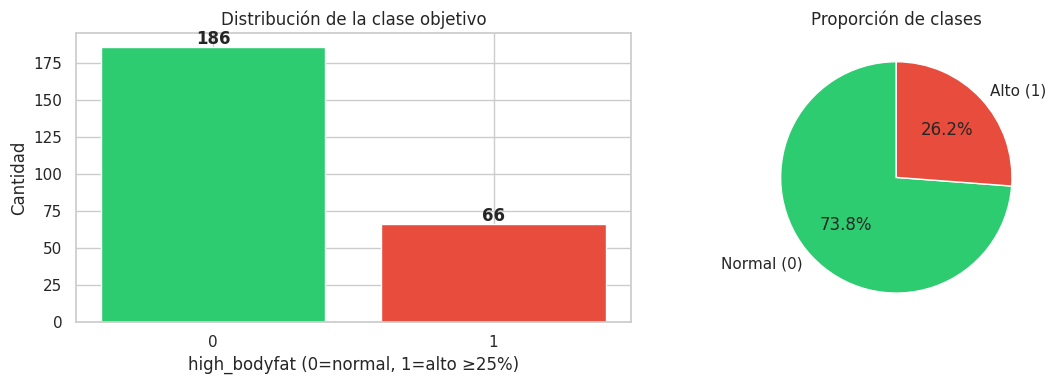

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df['high_bodyfat'].value_counts()
axes[0].bar(target_counts.index.astype(str), target_counts.values,
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución de la clase objetivo')
axes[0].set_xlabel('high_bodyfat (0=normal, 1=alto ≥25%)')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=['Normal (0)', 'Alto (1)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

***Distribución de variables numéricas clave:***

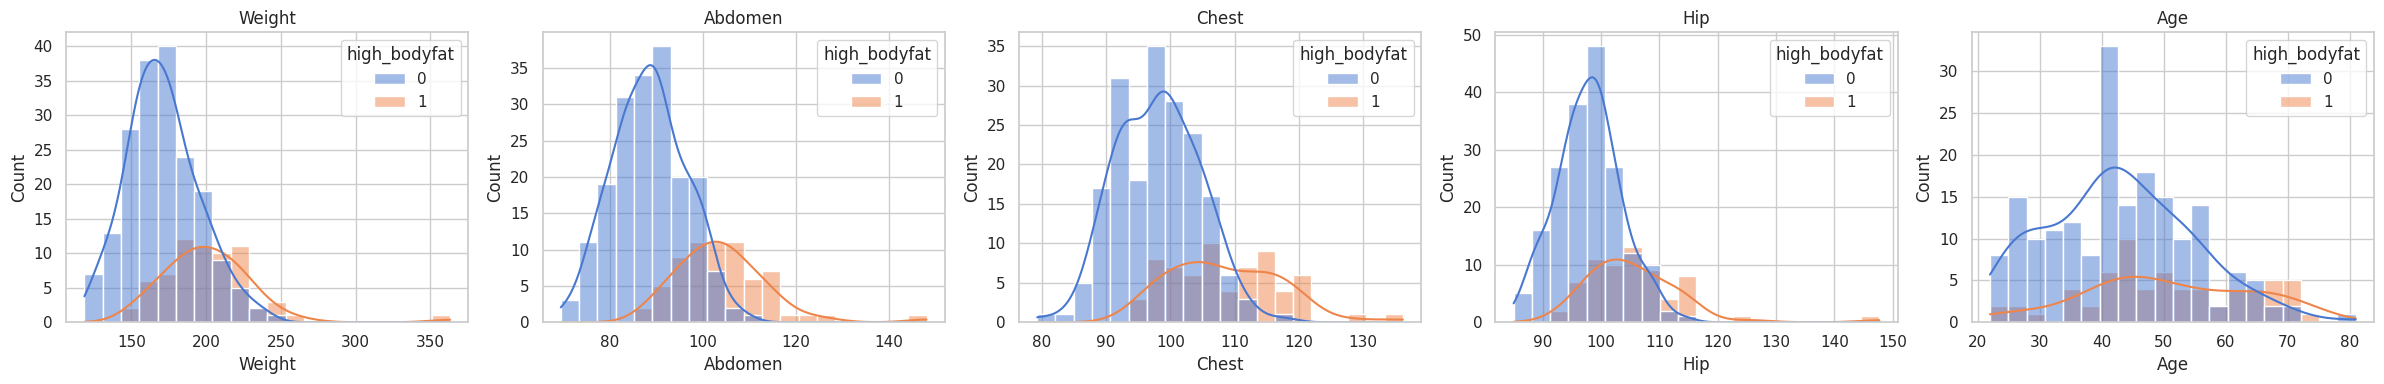

In [7]:
num_cols = ['Weight', 'Abdomen', 'Chest', 'Hip', 'Age']

fig, axes = plt.subplots(1, len(num_cols), figsize=(24, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='high_bodyfat', kde=True, ax=ax, bins=20)
    ax.set_title(col)
plt.tight_layout()
plt.show()

***Matriz de correlación:***

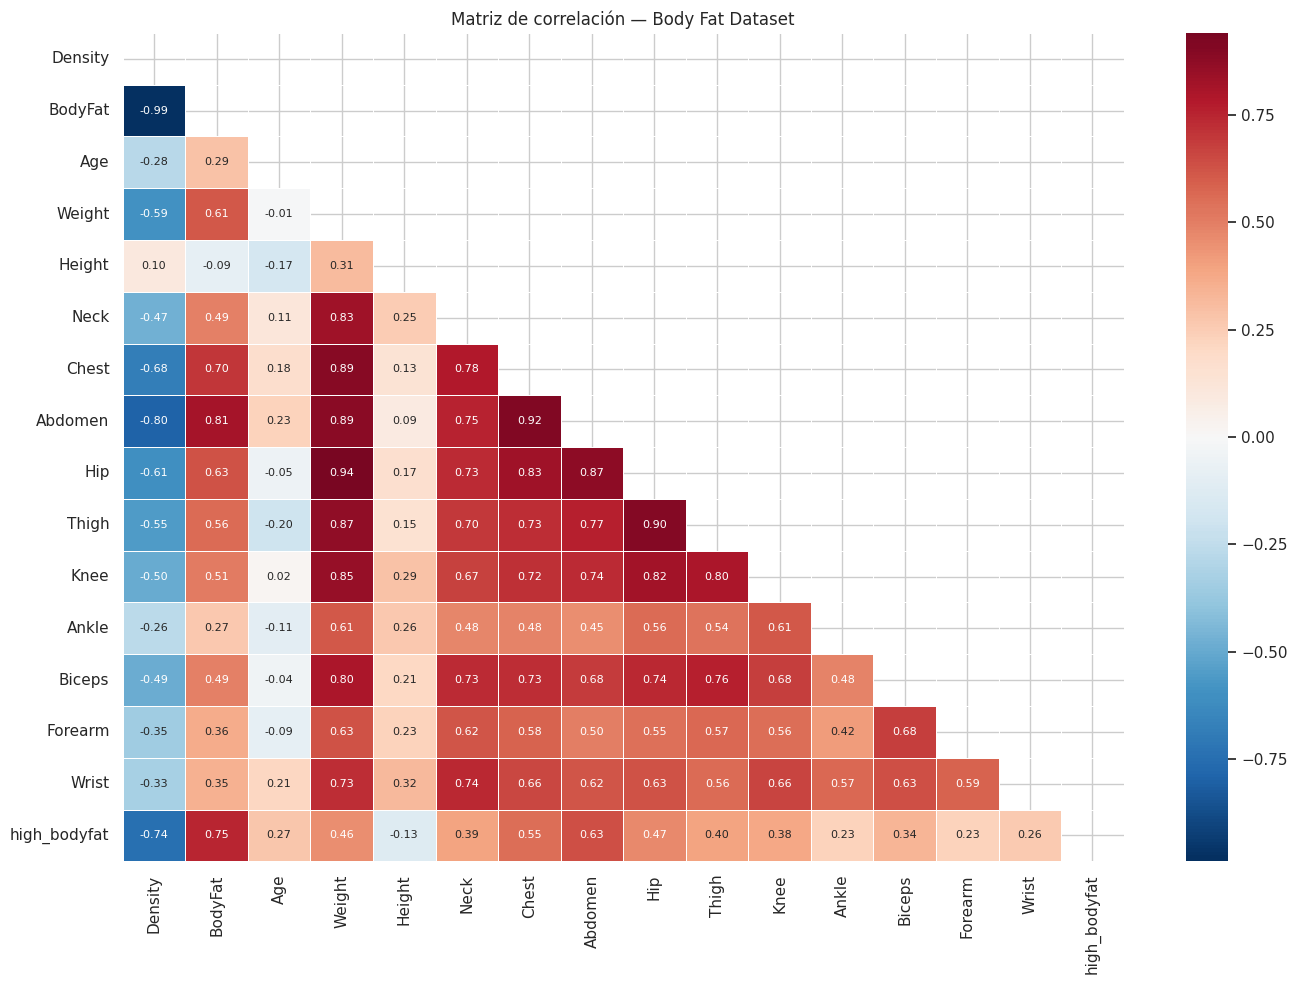

In [8]:
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de correlación — Body Fat Dataset')
plt.tight_layout()
plt.show()

***Features y target:***

In [9]:
# Excluimos BodyFat (es la fuente del target, la usaría "haciendo trampa")
# y Density (fórmula matemática directamente ligada al %BodyFat, mismo problema)
X = df.drop(columns=['BodyFat', 'Density', 'high_bodyfat'])
y = df['high_bodyfat']

print(f'Features: {X.shape}')
print(f'Target:   {y.shape}')
print(f'\nColumnas usadas como features: {list(X.columns)}')

Features: (252, 13)
Target:   (252,)

Columnas usadas como features: ['Age', 'Weight', 'Height', 'Neck', 'Chest', 'Abdomen', 'Hip', 'Thigh', 'Knee', 'Ankle', 'Biceps', 'Forearm', 'Wrist']


***Split train/test:***

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')
print(f'\nProporción target en train:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'\nProporción target en test:\n{y_test.value_counts(normalize=True).round(3)}')

Train: 201 muestras
Test:  51 muestras

Proporción target en train:
high_bodyfat
0    0.736
1    0.264
Name: proportion, dtype: float64

Proporción target en test:
high_bodyfat
0    0.745
1    0.255
Name: proportion, dtype: float64


***Pipelines y validación cruzada:***

In [11]:
pipelines = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42))
    ])
}

results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:25s}  Accuracy CV: {scores.mean():.4f} ± {scores.std():.4f}')

LogisticRegression         Accuracy CV: 0.8356 ± 0.0381
DecisionTree               Accuracy CV: 0.8160 ± 0.0403
RandomForest               Accuracy CV: 0.8306 ± 0.0407


***Comparación visual:***

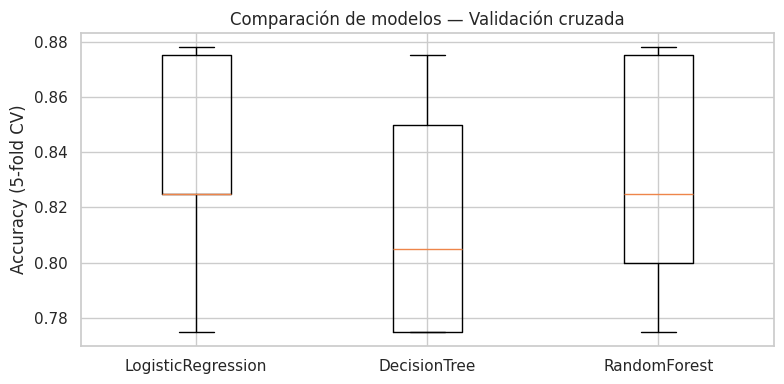

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(results.values(), tick_labels=results.keys())
ax.set_ylabel('Accuracy (5-fold CV)')
ax.set_title('Comparación de modelos — Validación cruzada')
plt.tight_layout()
plt.show()

***Mejor modelo y evaluación:***

In [13]:
best_name = max(results, key=lambda k: results[k].mean())
best_pipeline = pipelines[best_name]
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

print(f'Mejor modelo: {best_name}')
print(f'Accuracy en test: {best_pipeline.score(X_test, y_test):.4f}')
print('\n' + '='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Alto']))

Mejor modelo: LogisticRegression
Accuracy en test: 0.8824

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.90      0.95      0.92        38
        Alto       0.82      0.69      0.75        13

    accuracy                           0.88        51
   macro avg       0.86      0.82      0.84        51
weighted avg       0.88      0.88      0.88        51



***Matriz de confusión:***

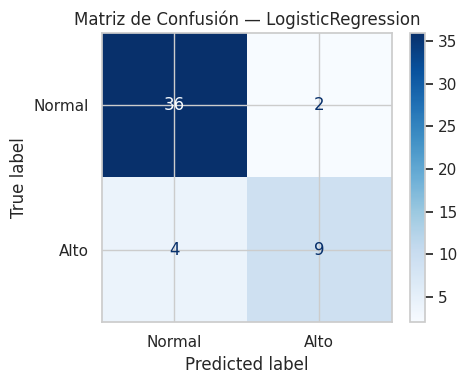

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Normal', 'Alto'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de Confusión — {best_name}')
plt.tight_layout()
plt.show()

***Curva ROC:***

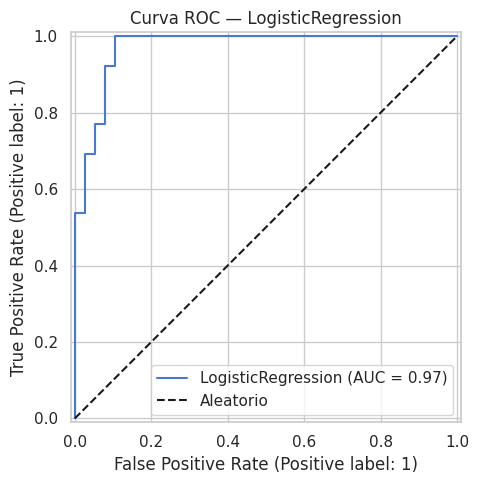

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(best_pipeline, X_test, y_test, ax=ax, name=best_name)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
ax.set_title(f'Curva ROC — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()

***Guardar el modelo:***

In [16]:
MODEL_PATH = 'bodyfat_model.joblib'
joblib.dump(best_pipeline, MODEL_PATH)
print(f'Modelo guardado en: {MODEL_PATH}')

Modelo guardado en: bodyfat_model.joblib


***Verificar:***

In [17]:
loaded_model = joblib.load(MODEL_PATH)
assert np.array_equal(loaded_model.predict(X_test), y_pred), 'Error: predicciones no coinciden'
print('Verificación OK: el modelo cargado reproduce las predicciones.')

Verificación OK: el modelo cargado reproduce las predicciones.


***Función de inferencia:***

In [29]:
def predict_bodyfat_level(person_data: dict) -> dict:
    """
    Recibe medidas corporales de una persona y predice si su nivel
    de grasa corporal es alto (≥25%) o normal.
    """
    model = joblib.load(MODEL_PATH)
    input_df = pd.DataFrame([person_data])[X.columns]

    pred = model.predict(input_df)[0]
    proba = model.predict_proba(input_df)[0]

    nivel = 'Alto' if pred == 1 else 'Normal'

    return {
        'nivel_predicho': nivel,
        'probabilidad_alto': round(float(proba[1]), 4),
        'probabilidad_normal': round(float(proba[0]), 4)
    }

persona_ejemplo = {
    'Age': 45, 'Weight': 210.0, 'Height': 69.0, 'Neck': 40.0,
    'Chest': 105.0, 'Abdomen': 100.0, 'Hip': 105.0, 'Thigh': 60.0,
    'Knee': 40.0, 'Ankle': 23.0, 'Biceps': 34.0, 'Forearm': 29.0, 'Wrist': 18.5
}

resultado = predict_bodyfat_level(persona_ejemplo)
print('\n--- Resultado de inferencia ---')
for k, v in resultado.items():
    print(f'  {k}: {v}')


--- Resultado de inferencia ---
  nivel_predicho: Alto
  probabilidad_alto: 0.5234
  probabilidad_normal: 0.4766
